In [ ]:
Cybercrime Text Classification Using NLP and Machine Learning

Goal:
Predict the "Crime Type" using text-based cybercrime incident.

Dataset:
Cybercrime_Dataset.xlsx

Sheet used:
Created_Cybercrime_dataset

Main model:
Multinomial Naive Bayes

In [1]:

# 1. Import Libraries

import re
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import RegexpTokenizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB


# Set a clean plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


In [2]:
# 2. Load Dataset

dataset_path = "Cybercrime_Dataset .xlsx"
sheet_name = "Created_Cybercrime_dataset"
# The actual column headers start on the third Excel row, so header=2 is used.
df = pd.read_excel(dataset_path, sheet_name=sheet_name, header=2)

In [3]:
# Remove unnamed empty columns created from Excel formatting.
df = df.loc[:, ~df.columns.astype(str).str.startswith("Unnamed")]

# Remove extra spaces from column names.
df.columns = df.columns.str.strip()

In [4]:
print("\nFirst 5 Rows:")
print(df.head())


First 5 Rows:
   SI No.             User/Victim         Date Country   Crime Type  \
0       1       Change Healthcare    Feb, 2024     USA   Ransomware   
1       2               Snowflake  April, 2024     USA  Data Breach   
2       3  UK Ministry of Defence    May, 2024      UK  Data Breach   
3       4               Ascension    May ,2024     USA   Ransomware   
4       5              MediSecure    Feb, 2024     USA  Data Breach   

          Attacker                        Key Reason for the Crime  \
0   ALPHV/BlackCat            Compromised Credentials, Lack of MFA   
1          UNC5537               Weaker Data security, Lack of MFA   
2  Suspected China  Outdated Security Patches, Poor Authentication   
3          Unknown            Compromised Credentials, Lack of MFA   
4      ID: UNC1234                         Compromised Credentials   

        Financial Loss                          Impact  \
0         $2.9 billion              Service Disruption   
1         $500 Millio

In [5]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(253, 14)


In [6]:
print("\nDataset Columns:")
print(df.columns.tolist())


Dataset Columns:
['SI No.', 'User/Victim', 'Date', 'Country', 'Crime Type', 'Attacker', 'Key Reason for the Crime', 'Financial Loss', 'Impact', 'Affected Systems', 'Data Compromised', 'Detection Method', 'Ransom Amount(Approx)', 'Key takeaway']


In [7]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   SI No.                    253 non-null    int64 
 1   User/Victim               196 non-null    object
 2   Date                      196 non-null    object
 3   Country                   196 non-null    object
 4   Crime Type                196 non-null    object
 5   Attacker                  196 non-null    object
 6   Key Reason for the Crime  196 non-null    object
 7   Financial Loss            53 non-null     object
 8   Impact                    196 non-null    object
 9   Affected Systems          196 non-null    object
 10  Data Compromised          196 non-null    object
 11  Detection Method          196 non-null    object
 12  Ransom Amount(Approx)     37 non-null     object
 13  Key takeaway              196 non-null    object
dtypes: i

In [8]:
# 3. Data Cleaning

print("\nDuplicate rows before cleaning:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicate rows after cleaning:", df.duplicated().sum())

print("\nMissing values before cleaning:")
print(df.isnull().sum())

text_column = "Key Reason for the Crime"
target_column = "Crime Type"

# Keep only rows where both text and target values are available.
df = df.dropna(subset=[text_column, target_column])

# Fill missing values in other columns with a simple placeholder.
df = df.fillna("Unknown")

# Reset index after dropping rows.
df = df.reset_index(drop=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())


Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0

Missing values before cleaning:
SI No.                        0
User/Victim                  57
Date                         57
Country                      57
Crime Type                   57
Attacker                     57
Key Reason for the Crime     57
Financial Loss              200
Impact                       57
Affected Systems             57
Data Compromised             57
Detection Method             57
Ransom Amount(Approx)       216
Key takeaway                 57
dtype: int64

Missing values after cleaning:
SI No.                      0
User/Victim                 0
Date                        0
Country                     0
Crime Type                  0
Attacker                    0
Key Reason for the Crime    0
Financial Loss              0
Impact                      0
Affected Systems            0
Data Compromised            0
Detection Method            0
Ransom Amount(Approx)       0
Key takeaway    

In [9]:
def clean_text(text):
    """Clean raw text using lowercase conversion and regex cleaning."""

    # Convert text to lowercase string.
    text = str(text).lower()

    # Remove punctuation, numbers, and special characters.
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces.
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Create a cleaned text column.
df["clean_text"] = df[text_column].apply(clean_text)

print("\nOriginal and Cleaned Text Examples:")
print(df[[text_column, "clean_text"]].head())


Original and Cleaned Text Examples:
                         Key Reason for the Crime  \
0            Compromised Credentials, Lack of MFA   
1               Weaker Data security, Lack of MFA   
2  Outdated Security Patches, Poor Authentication   
3            Compromised Credentials, Lack of MFA   
4                         Compromised Credentials   

                                      clean_text  
0            compromised credentials lack of mfa  
1               weaker data security lack of mfa  
2  outdated security patches poor authentication  
3            compromised credentials lack of mfa  
4                        compromised credentials  


In [10]:
# 4. Select NLP Text Column

X_text = df["clean_text"]
y = df[target_column].astype(str)

print("\nSample Cleaned Text:")
print(X_text.head())

print("\nSample Target Values:")
print(y.head())



Sample Cleaned Text:
0              compromised credentials lack of mfa
1                 weaker data security lack of mfa
2    outdated security patches poor authentication
3              compromised credentials lack of mfa
4                          compromised credentials
Name: clean_text, dtype: object

Sample Target Values:
0     Ransomware
1    Data Breach
2    Data Breach
3     Ransomware
4    Data Breach
Name: Crime Type, dtype: object


In [11]:
# 5. Text Preprocessing

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    nltk.download("stopwords", quiet=True)

try:
    stop_words = set(stopwords.words("english"))
except LookupError:
    # Fallback stopword list if NLTK stopwords cannot be downloaded.
    stop_words = set(
        """
        a an and are as at be by for from has he in is it its of on that the to was were
        will with this these those into over under between through due lack poor weak
        """.split()
    )

tokenizer = RegexpTokenizer(r"[a-z]+")
stemmer = PorterStemmer()


def preprocess_text(text):
    """Tokenize text, remove stopwords, and apply stemming."""

    # Split text into word tokens.
    tokens = tokenizer.tokenize(text)

    # Remove stopwords and very short words.
    tokens = [word for word in tokens if word not in stop_words and len(word) > 2]

    # Apply stemming.
    stemmed_tokens = [stemmer.stem(word) for word in tokens]

    # Join processed tokens back into a sentence.
    return " ".join(stemmed_tokens)


df["processed_text"] = df["clean_text"].apply(preprocess_text)

print("\nText After Preprocessing:")
print(df[[text_column, "clean_text", "processed_text"]].head())


Text After Preprocessing:
                         Key Reason for the Crime  \
0            Compromised Credentials, Lack of MFA   
1               Weaker Data security, Lack of MFA   
2  Outdated Security Patches, Poor Authentication   
3            Compromised Credentials, Lack of MFA   
4                         Compromised Credentials   

                                      clean_text  \
0            compromised credentials lack of mfa   
1               weaker data security lack of mfa   
2  outdated security patches poor authentication   
3            compromised credentials lack of mfa   
4                        compromised credentials   

                    processed_text  
0      compromis credenti lack mfa  
1       weaker data secur lack mfa  
2  outdat secur patch poor authent  
3      compromis credenti lack mfa  
4               compromis credenti  


C:\Users\Meena\AppData\Local\Temp\ipykernel_17644\3415264594.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


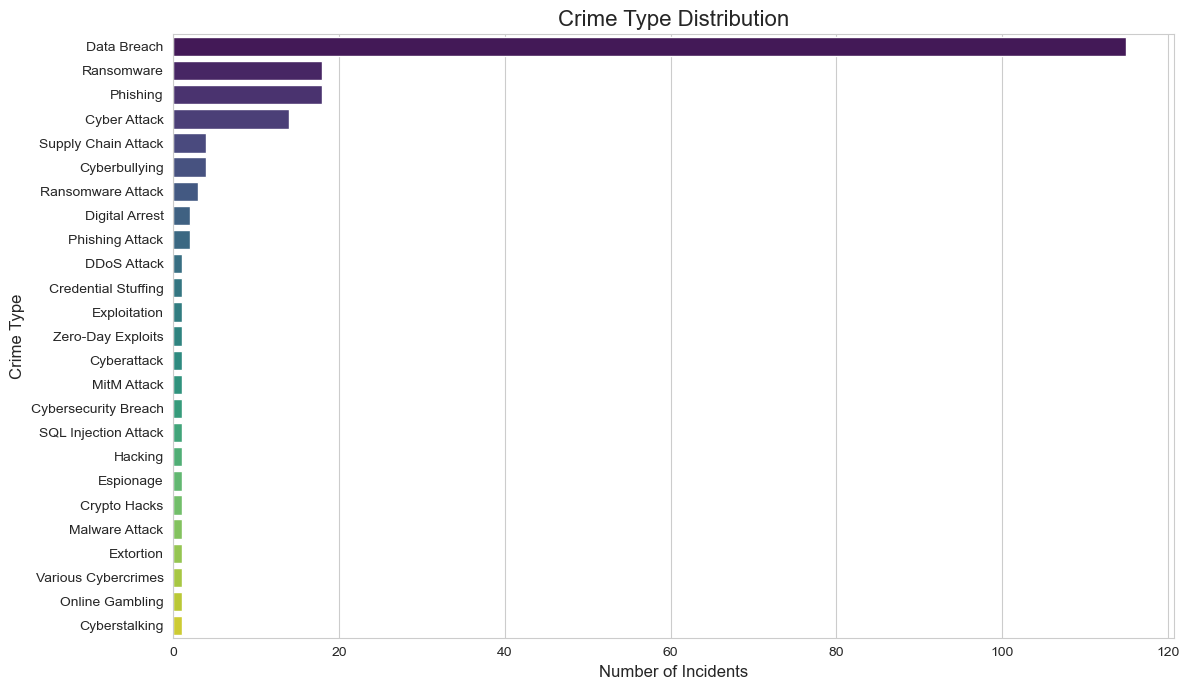

In [12]:
# 6. Exploratory Data Analysis

# Crime type distribution countplot.
plt.figure(figsize=(12, 7))
sns.countplot(
    data=df,
    y=target_column,
    order=df[target_column].value_counts().index,
    palette="viridis",
)
plt.title("Crime Type Distribution", fontsize=16)
plt.xlabel("Number of Incidents", fontsize=12)
plt.ylabel("Crime Type", fontsize=12)
plt.tight_layout()
plt.show()


Top 20 Common Words:
         Word  Frequency
0     financi         82
1        gain         81
2        data         63
3       theft         61
4    espionag         13
5       secur         10
6    credenti          7
7         mfa          7
8     exploit          6
9      vulner          5
10  compromis          4
11       lack          4
12    inadequ          4
13    disrupt          4
14     poorli          4
15       miss          3
16     target          3
17     person          3
18     social          2
19     malici          2


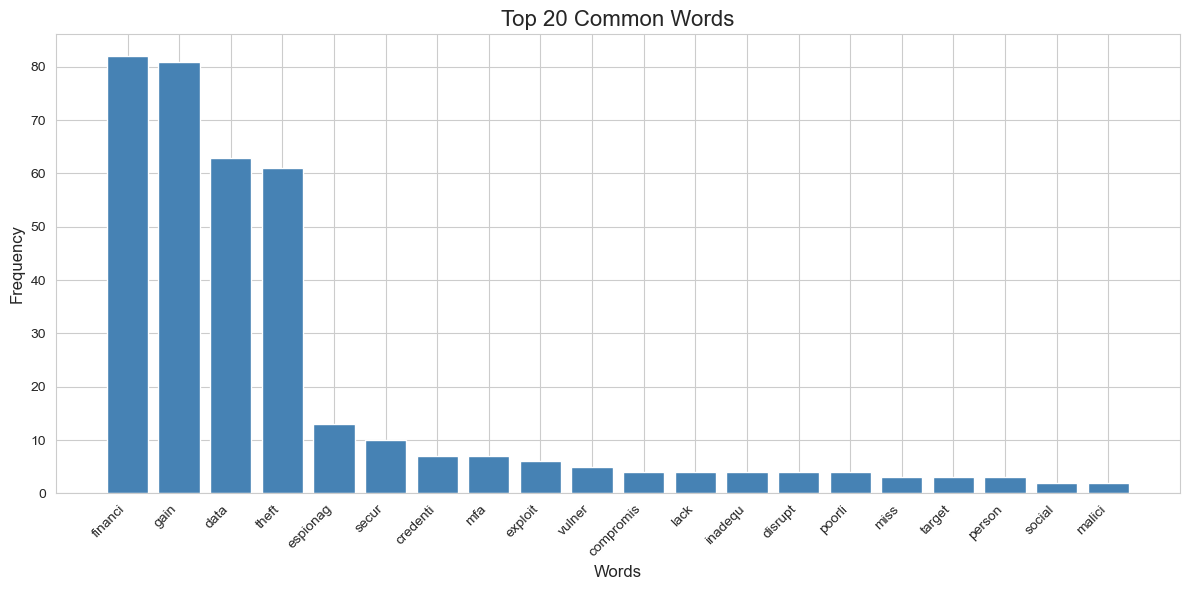

In [13]:
# Top common words.
all_words = " ".join(df["processed_text"]).split()
word_frequencies = Counter(all_words)
top_words = word_frequencies.most_common(20)
top_words_df = pd.DataFrame(top_words, columns=["Word", "Frequency"])

print("\nTop 20 Common Words:")
print(top_words_df)

plt.figure(figsize=(12, 6))
plt.bar(top_words_df["Word"], top_words_df["Frequency"], color="steelblue")
plt.title("Top 20 Common Words", fontsize=16)
plt.xlabel("Words", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

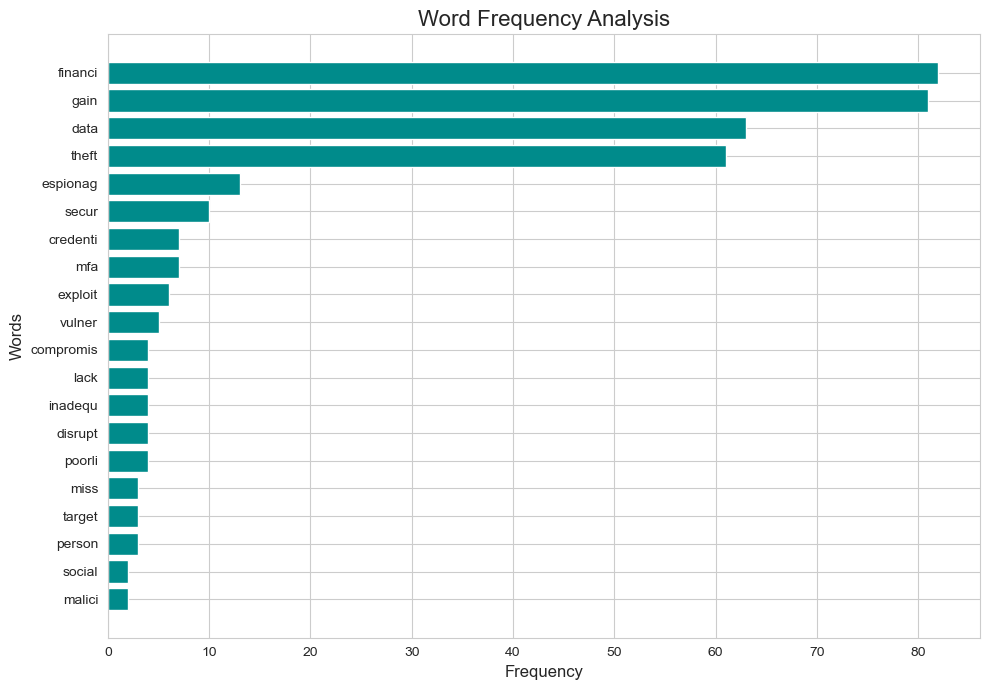

In [14]:
# Word frequency analysis.
plt.figure(figsize=(10, 7))
plt.barh(top_words_df["Word"], top_words_df["Frequency"], color="darkcyan")
plt.title("Word Frequency Analysis", fontsize=16)
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Words", fontsize=12)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

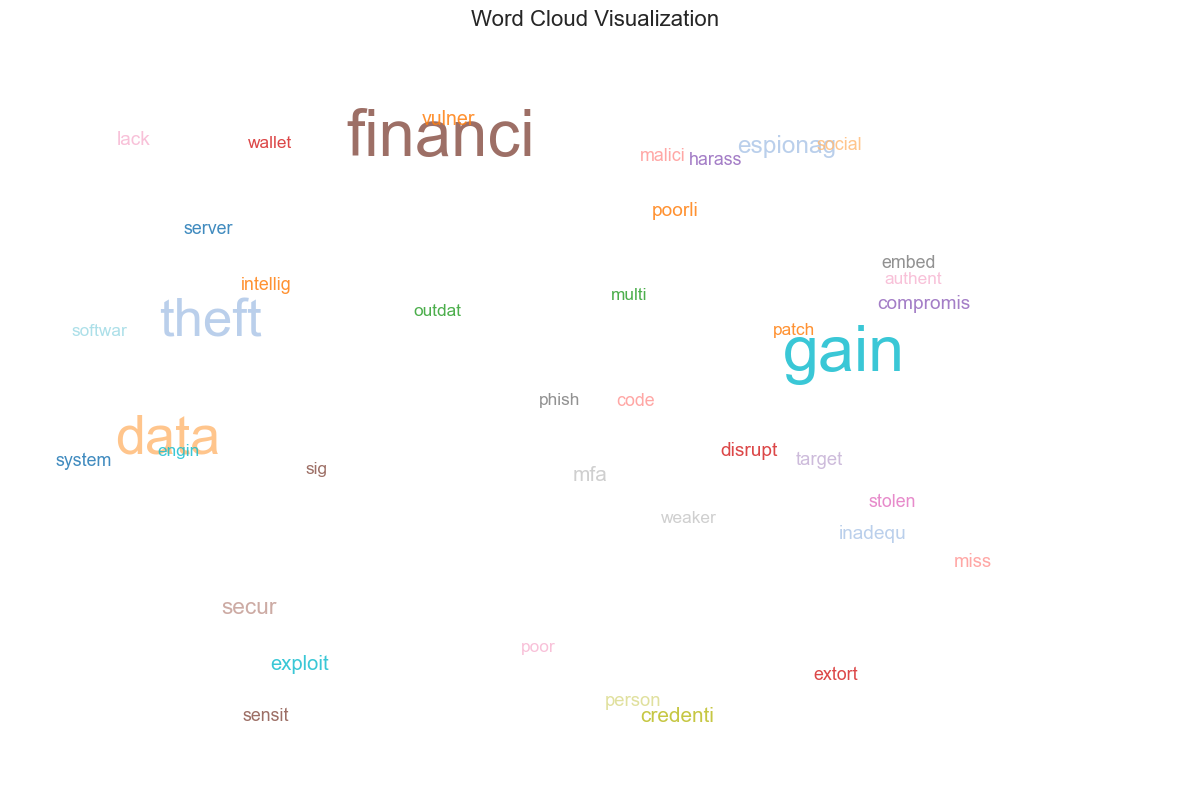

In [15]:
def plot_matplotlib_word_cloud(word_freq, max_words=40):
    """Create a simple word cloud-style plot using Matplotlib only."""

    most_common_words = word_freq.most_common(max_words)

    if not most_common_words:
        print("No words available for word cloud visualization.")
        return

    frequencies = [frequency for _, frequency in most_common_words]
    max_frequency = max(frequencies)

    np.random.seed(42)

    plt.figure(figsize=(12, 8))
    ax = plt.gca()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    for word, frequency in most_common_words:
        x_position = np.random.uniform(0.05, 0.9)
        y_position = np.random.uniform(0.08, 0.9)
        font_size = 12 + (frequency / max_frequency) * 35
        color = plt.cm.tab20(np.random.randint(0, 20))

        ax.text(
            x_position,
            y_position,
            word,
            fontsize=font_size,
            color=color,
            ha="center",
            va="center",
            alpha=0.85,
        )

    plt.title("Word Cloud Visualization", fontsize=16)
    plt.tight_layout()
    plt.show()


plot_matplotlib_word_cloud(word_frequencies)

In [16]:
# 7. TF-IDF Vectorization

tfidf_vectorizer = TfidfVectorizer(max_features=1000)
X_tfidf = tfidf_vectorizer.fit_transform(df["processed_text"])

print("\nTF-IDF Matrix Shape:")
print(X_tfidf.shape)



TF-IDF Matrix Shape:
(196, 61)


In [17]:
# 8. Train-Test Split

class_counts = y.value_counts()
stratify_values = y if class_counts.min() >= 2 else None

if stratify_values is None:
    print("\nSome crime types have only one record.")
    print("Train-test split is done without stratification.")

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=stratify_values,
)

print("\nTraining records:", X_train.shape[0])
print("Testing records:", X_test.shape[0])


Some crime types have only one record.
Train-test split is done without stratification.

Training records: 156
Testing records: 40


In [18]:
# 9. Build Naive Bayes Model

naive_bayes_model = MultinomialNB()
naive_bayes_model.fit(X_train, y_train)

print("\nNaive Bayes model training completed successfully.")


Naive Bayes model training completed successfully.


In [19]:
# 10. Prediction

y_pred = naive_bayes_model.predict(X_test)

prediction_results = pd.DataFrame(
    {
        "Actual Crime Type": y_test.values,
        "Predicted Crime Type": y_pred,
    }
)

print("\nFirst 10 Predictions:")
print(prediction_results.head(10))


First 10 Predictions:
  Actual Crime Type Predicted Crime Type
0       Data Breach          Data Breach
1      Cyber Attack          Data Breach
2      Cyber Attack          Data Breach
3       Data Breach          Data Breach
4       Data Breach          Data Breach
5       Data Breach          Data Breach
6       Data Breach          Data Breach
7       Data Breach          Data Breach
8       Data Breach          Data Breach
9       Data Breach          Data Breach


In [20]:
# 11. Model Evaluation

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("\nModel Evaluation Metrics")
print("------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


Model Evaluation Metrics
------------------------
Accuracy : 0.6750
Precision: 0.4556
Recall   : 0.6750
F1 Score : 0.5440

Classification Report:
                      precision    recall  f1-score   support

        Cyber Attack       0.00      0.00      0.00         3
         Data Breach       0.68      1.00      0.81        27
      Digital Arrest       0.00      0.00      0.00         1
            Phishing       0.00      0.00      0.00         2
     Phishing Attack       0.00      0.00      0.00         1
          Ransomware       0.00      0.00      0.00         3
   Ransomware Attack       0.00      0.00      0.00         2
SQL Injection Attack       0.00      0.00      0.00         1

            accuracy                           0.68        40
           macro avg       0.08      0.12      0.10        40
        weighted avg       0.46      0.68      0.54        40



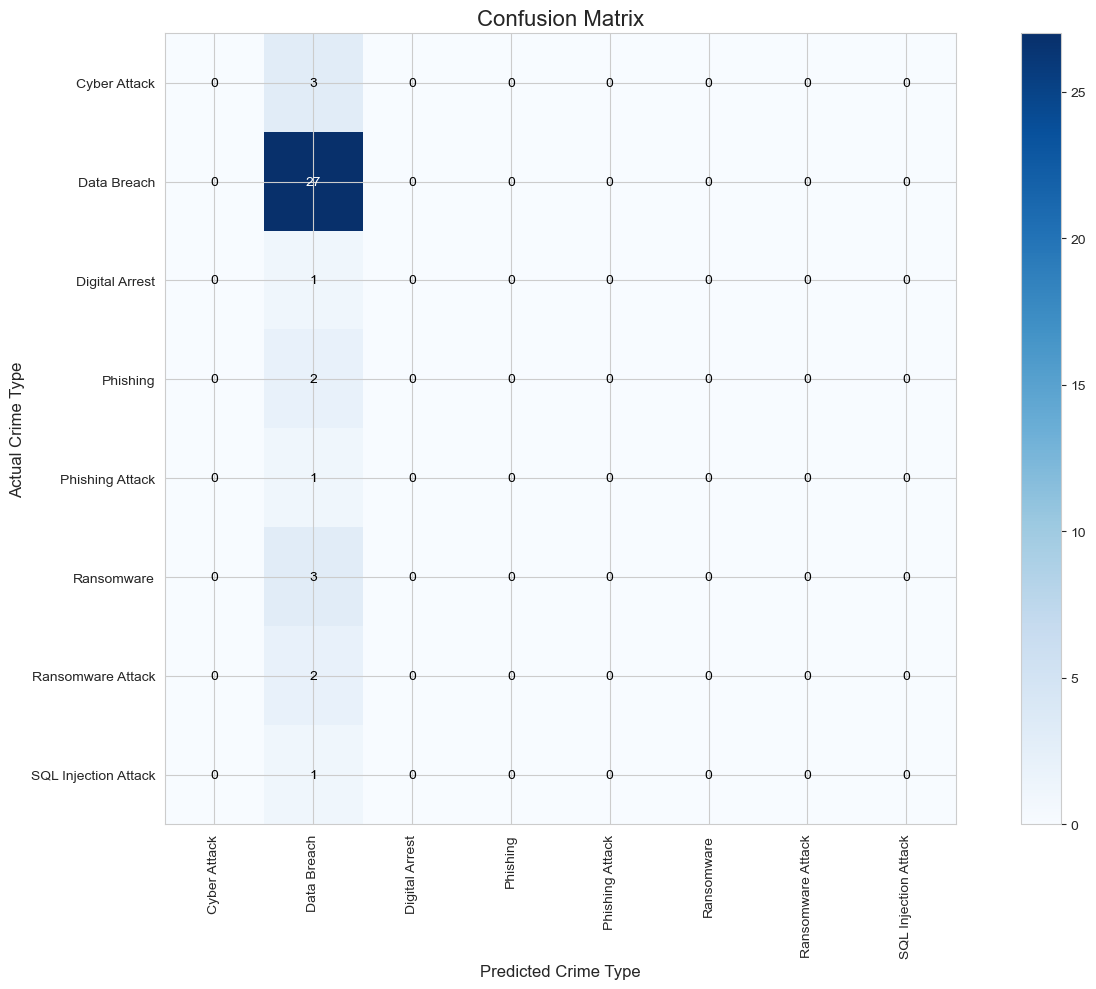

In [21]:
confusion_labels = sorted(pd.Series(list(y_test) + list(y_pred)).unique())
cm = confusion_matrix(y_test, y_pred, labels=confusion_labels)

plt.figure(figsize=(14, 10))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix", fontsize=16)
plt.colorbar()

tick_marks = np.arange(len(confusion_labels))
plt.xticks(tick_marks, confusion_labels, rotation=90)
plt.yticks(tick_marks, confusion_labels)

plt.xlabel("Predicted Crime Type", fontsize=12)
plt.ylabel("Actual Crime Type", fontsize=12)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )

plt.tight_layout()
plt.show()

In [22]:
# Predict Crime Type from New Text

def predict_crime_type(description):
    """Predict the cybercrime type for a new text description."""

    cleaned_description = clean_text(description)
    processed_description = preprocess_text(cleaned_description)
    description_tfidf = tfidf_vectorizer.transform([processed_description])
    predicted_crime_type = naive_bayes_model.predict(description_tfidf)[0]

    return predicted_crime_type


sample_description = (
    "The attacker used weak passwords and lack of multi factor authentication "
    "to steal user data."
)

predicted_type = predict_crime_type(sample_description)

print("\nSample Description:")
print(sample_description)
print("\nPredicted Crime Type:", predicted_type)


Sample Description:
The attacker used weak passwords and lack of multi factor authentication to steal user data.

Predicted Crime Type: Data Breach


In [23]:
# 12. Final Conclusion

print("\nFinal Conclusion")
print("----------------")
print("This project built an end-to-end Cybercrime Text Classification model.")
print("The model predicts Crime Type using the Key Reason for the Crime text column.")
print("Text was cleaned, preprocessed with NLTK, vectorized using TF-IDF, and modeled using Multinomial Naive Bayes.")
print("The model was evaluated using accuracy, precision, recall, F1 score, classification report, and confusion matrix.")
print("This type of model can help organize cybercrime reports and support early incident classification.")
print("More balanced data across crime types can improve future model performance.")



Final Conclusion
----------------
This project built an end-to-end Cybercrime Text Classification model.
The model predicts Crime Type using the Key Reason for the Crime text column.
Text was cleaned, preprocessed with NLTK, vectorized using TF-IDF, and modeled using Multinomial Naive Bayes.
The model was evaluated using accuracy, precision, recall, F1 score, classification report, and confusion matrix.
This type of model can help organize cybercrime reports and support early incident classification.
More balanced data across crime types can improve future model performance.
